# 01 — Defining Spp1+ macrophages, validating them, and asking where they live

**This script is the foundation. Nothing downstream is trustworthy until this one passes.**

It answers your question *"In what conditions do the Spp1 macrophages tend to be found the most?"*
and, more importantly, it **stress-tests the Spp1+ definition** before we build hotspot /
neighborhood / LR analyses on top of it.

### Why the definition needs stress-testing
Your original snippet was `mac AND Spp1 > 0`. Two problems in *this* dataset:

1. **`c2l_winner` does not exist here.** The HPC store (`1_C2l_annotated_CC`) has
   `c2l_argmax / c2l_permissive / c2l_strict / c2l_runnerup / c2l_consolidated`.
   The column carrying `M1_like_Mac / M2_like_Mac / Intermediate_Mac` is **`c2l_consolidated`**
   (81,565 macrophages total). That snippet came from your older CellCharter object.
2. **`Spp1 > 0` on segmented spatial data is a low bar.** Spp1 is a highly-expressed *secreted*
   transcript, so nuclei-segmented cells pick up ambient/spillover reads from neighbors. At
   `>0` you may be labelling "macrophage sitting next to an Spp1-high cell" as an Spp1+ TAM.
   That would manufacture exactly the spatial association we are trying to test — a circularity
   that would quietly invalidate every downstream result.

So this script sweeps the threshold, and validates each candidate definition against an
**independent SPP1-TAM program** (Trem2/Gpnmb/Apoe/Fabp5/Marco...) taken from the PDF's
readout list. A real Spp1+ TAM state should be TREM2/lipid-high *without us asking it to be*.
If the module score doesn't separate, the definition is picking up ambient noise.

**Deliverables:** cell-type vocabulary check; threshold sweep; TAM-module validation;
Spp1+ mac abundance per condition (replicate-level, both denominators); RT contrasts.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

import scanpy as sc
import spatialdata as spd

from scipy.stats import mannwhitneyu

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 1. Configuration

Paths mirror `Hotspot_Abscopal_Comparison.ipynb` (the HPC store). Everything is defined
**inline** — the kernel runs on the HPC node and cannot see local `.py` files.

In [2]:
PROJ_DIR    = Path("/coh_labs/yunroseli/Jona/CAR-T")
ZARR_FILE   = PROJ_DIR / "data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
PATHWAY_DIR = PROJ_DIR / "data/references/pathways"
OUT_DIR     = PROJ_DIR / "results/spp1_analysis"
FIG_DIR     = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- obs columns ---
TISSUE_COL    = "tissue"
CELL_TYPE_COL = "c2l_consolidated"   # <-- the column with M1/M2/Intermediate_Mac (NOT c2l_permissive)
CONDITION_COL = "condition"
MOUSE_COL     = "mouse"

MAC_LABELS = ["M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"]

# Spp1+ threshold sweep (raw UMI counts, from layers["counts"])
SPP1_THRESHOLDS = [1, 2, 3, 5]
SPP1_THRESHOLD_DEFAULT = 2      # revisit after looking at the sweep + module validation below

MIN_CELLS_PER_TISSUE = 100

print("config ready ->", OUT_DIR)

config ready -> /coh_labs/yunroseli/Jona/CAR-T/results/spp1_analysis


## 2. Load data

`.X` is log1p-normalized (see `uns['normalization']`); `layers['counts']` holds raw UMIs.
Thresholding is done on **counts** so "Spp1 >= k UMI" means what it says.

In [3]:
sdata = spd.read_zarr(ZARR_FILE)
adata = sdata.tables["segmentation_counts"]

print(adata)
print("\nnormalization :", adata.uns.get("normalization"))
print("has counts layer:", "counts" in adata.layers)
print("tissues        :", adata.obs[TISSUE_COL].nunique())

AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment', '_scvi_batch', '_scvi_labels', 'X_cc_01', 'X_cc_1', 'X_cc_012', 'X_cc_2', 'X_cc_0'
    uns: 'normalization', '_scvi_uuid', '_scvi_manager_uuid', 'spatial_neighbors', 'condition_colors', 'spatialdata_attrs', 'log1p'
    obsm: 'c2l_q95', 'X_cc_1', 'X_cc_01', 'X_cc_012', 'spatial', 'X_scVI', 'c2l_means', 'X_cc_2', 'c2l_q05', 'X_cc_0'
    layers: 'counts'
    obsp: 'spatial_distances', 'spatial_connectivities'

normalization : {'target_sum': 10000.0, 'raw_counts_layer': 'counts', 'method': 'scanpy.pp.normalize_total + log1p'}
has counts layer: True
tissues        : 32


## 3. Cell-type vocabulary check (fail fast)

Confirms the macrophage labels actually exist before anything depends on them.

In [4]:
assert CELL_TYPE_COL in adata.obs.columns, f"{CELL_TYPE_COL} not in obs: {list(adata.obs.columns)}"

ct_counts = adata.obs[CELL_TYPE_COL].astype(str).value_counts()
print(f"--- {CELL_TYPE_COL} vocabulary ({len(ct_counts)} labels) ---")
print(ct_counts.to_string())

missing_macs = [m for m in MAC_LABELS if m not in set(ct_counts.index)]
assert not missing_macs, f"macrophage labels missing from {CELL_TYPE_COL}: {missing_macs}"

n_mac = int(ct_counts.reindex(MAC_LABELS).sum())
print(f"\nmacrophages ({' + '.join(MAC_LABELS)}): {n_mac:,} "
      f"({100*n_mac/adata.n_obs:.2f}% of {adata.n_obs:,} cells)")
print(f"Unknown fraction: {100*ct_counts.get('Unknown',0)/adata.n_obs:.1f}% "
      "(these are excluded from every denominator below)")

--- c2l_consolidated vocabulary (25 labels) ---
c2l_consolidated
Unknown              671434
Cancer_cell          363019
Erythrocyte          210019
N2_like_Neu          193240
Neutrophil           184827
N1_like_Neu          134656
M2_like_Mac           60720
Classical_Mono        58279
CD8_T                 45824
B                     40422
Fibroblast            24867
NK                    22924
M1_like_Mac           19170
Endothelial           17702
CD4_T                 10085
cDC                    8471
NKT                    7110
Treg                   5155
pDC                    4558
Nonclassical_Mono      4002
Intermediate_Mac       1675
Macrophage              145
Tcell                   120
Monocyte                113
DC                       20

macrophages (M1_like_Mac + M2_like_Mac + Intermediate_Mac): 81,565 (3.91% of 2,088,557 cells)
Unknown fraction: 32.1% (these are excluded from every denominator below)


## 4. Design table (condition x tumor location x replicate)

Parsed from the `tissue` string `COND_loc_rep`. Per your convention, in RT groups
**tumor_loc 1 = directly irradiated**, **tumor_loc 2 = never irradiated (abscopal)**.

In [5]:
def parse_tissue(t):
    m = re.match(r"^(.*)_(\d+)_(\d+)$", str(t))
    return (m.group(1), int(m.group(2)), int(m.group(3))) if m else (None, None, None)

tissues_all = sorted(adata.obs[TISSUE_COL].astype(str).unique())
design = pd.DataFrame({"tissue": tissues_all})
design[["cond", "tumor_loc", "rep"]] = design["tissue"].apply(lambda t: pd.Series(parse_tissue(t)))
design["irradiated"] = design["cond"].str.startswith("RT") & design["tumor_loc"].eq(1)
design["rt_group"]   = np.where(~design["cond"].str.startswith("RT"), "no_RT",
                        np.where(design["tumor_loc"].eq(1), "RT_direct", "RT_abscopal"))
design["group"] = design["cond"] + "_" + design["tumor_loc"].astype(str)

print("--- design ---")
print(design.groupby(["cond", "tumor_loc"], observed=True).size().rename("n_tissues").to_string())
print("\ntissues per rt_group:")
print(design["rt_group"].value_counts().to_string())

tissue_meta = design.set_index("tissue")

--- design ---
cond      tumor_loc
CyPSCA    1            4
          2            4
CyT72     1            2
          2            2
NoTx      1            4
          2            4
RTCyPSCA  1            4
          2            2
RTCyT72   1            3
          2            3

tissues per rt_group:
rt_group
no_RT          20
RT_direct       7
RT_abscopal     5


## 5. Spp1 expression: threshold sweep within the macrophage compartment

How many macrophages survive each Spp1 cutoff — and, as a **spillover control**, the same
cutoff applied to a cell type that should *not* be making Spp1 (B cells). If the Spp1+ rate
in B cells tracks the rate in macrophages, that cutoff is reading ambient RNA, not biology.

In [6]:
assert "Spp1" in adata.var_names, "Spp1 not in var_names"

counts = adata.layers["counts"]
spp1_i = int(adata.var_names.get_loc("Spp1"))
spp1_counts = counts[:, spp1_i]
spp1_counts = np.asarray(spp1_counts.todense()).ravel() if sp.issparse(spp1_counts) else np.asarray(spp1_counts).ravel()
adata.obs["Spp1_counts"] = spp1_counts

ct = adata.obs[CELL_TYPE_COL].astype(str)
mac_mask = ct.isin(MAC_LABELS).values
ctrl_label = "B" if "B" in set(ct) else ct.value_counts().index[0]
ctrl_mask = (ct == ctrl_label).values

sweep = []
for thr in SPP1_THRESHOLDS:
    pos = spp1_counts >= thr
    sweep.append({
        "threshold": f">= {thr} UMI",
        "n_mac_Spp1pos": int((mac_mask & pos).sum()),
        "pct_of_macs": 100 * (mac_mask & pos).sum() / mac_mask.sum(),
        f"pct_of_{ctrl_label}_cells (spillover ctrl)": 100 * (ctrl_mask & pos).sum() / max(ctrl_mask.sum(), 1),
        "pct_all_cells": 100 * pos.sum() / adata.n_obs,
    })
sweep_df = pd.DataFrame(sweep)

print(f"--- Spp1 threshold sweep (control cell type = {ctrl_label}) ---")
print(sweep_df.round(2).to_string(index=False))
print(f"\nSpp1 counts in macrophages: median={np.median(spp1_counts[mac_mask]):.0f} "
      f"mean={spp1_counts[mac_mask].mean():.2f} max={spp1_counts[mac_mask].max():.0f}")
print(f"macrophages with Spp1 == 0: {100*(spp1_counts[mac_mask]==0).mean():.1f}%")
print("\nREAD THIS: if 'pct_of_%s' stays close to 'pct_of_macs' as the threshold rises,"
      "\nthe low cutoffs are ambient spillover -> prefer a higher SPP1_THRESHOLD_DEFAULT." % ctrl_label)

--- Spp1 threshold sweep (control cell type = B) ---
threshold  n_mac_Spp1pos  pct_of_macs  pct_of_B_cells (spillover ctrl)  pct_all_cells
 >= 1 UMI          65835        80.71                            95.74          80.24
 >= 2 UMI          52984        64.96                            89.50          67.91
 >= 3 UMI          43291        53.08                            82.31          58.95
 >= 5 UMI          30452        37.33                            67.67          45.96

Spp1 counts in macrophages: median=3 mean=7.01 max=759
macrophages with Spp1 == 0: 19.3%

READ THIS: if 'pct_of_B' stays close to 'pct_of_macs' as the threshold rises,
the low cutoffs are ambient spillover -> prefer a higher SPP1_THRESHOLD_DEFAULT.


## 6. Independent validation: does the Spp1+ mac call recover a real SPP1-TAM program?

The PDF's readout panel, as a module score computed on **all macrophages**. This is the
honest test: we never used these genes to make the call, so if `Spp1+` macs score higher
on TREM2/lipid-handling than `Spp1-` macs, the label is tracking a real state.

`Spp1` itself is deliberately **excluded** from the module — including it would guarantee
separation and prove nothing.

In [10]:
SPP1_TAM_MODULE = {
    # lipid-handling / TREM2 axis (the PDF's primary mechanism)
    "TAM_lipid_TREM2": ["Trem2", "Gpnmb", "Apoe", "Fabp5", "Marco", "Cd63", "Lgals3",
                        "Ctsb", "Ctsd", "Lpl", "Abca1", "Abcg1", "Cd36", "Msr1", "Plin2"],
    # adenosine machinery (CD39/CD73)
    "TAM_adenosine":   ["Entpd1", "Nt5e", "Adora2a", "Adora2b"],
    # efferocytosis / wound-repair
    "TAM_efferocytosis": ["Mertk", "Axl", "Gas6", "Timd4", "Anxa1", "C1qa", "C1qb", "C1qc"],
    # hypoxia-adapted
    "TAM_hypoxia":     ["Hif1a", "Vegfa", "Slc2a1", "Ldha", "Bnip3", "Ero1a"],
}

for name, genes in SPP1_TAM_MODULE.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    if len(present) < 3:
        print(f"[skip] {name}: only {len(present)} genes present")
        continue
    sc.tl.score_genes(adata, gene_list=present, score_name=name, use_raw=False, random_state=0)
    print(f"[ok] {name}: {len(present)}/{len(genes)} genes"
          + (f" | missing: {missing}" if missing else ""))

[ok] TAM_lipid_TREM2: 15/15 genes
[ok] TAM_adenosine: 4/4 genes
[ok] TAM_efferocytosis: 8/8 genes
[ok] TAM_hypoxia: 5/6 genes | missing: ['Ero1a']


In [11]:
# Compare module scores: Spp1+ vs Spp1- macrophages, at each candidate threshold.
module_cols = [m for m in SPP1_TAM_MODULE if m in adata.obs.columns]
mac_obs = adata.obs.loc[mac_mask, module_cols + ["Spp1_counts"]].copy()

rows = []
for thr in SPP1_THRESHOLDS:
    pos = (mac_obs["Spp1_counts"] >= thr).values
    if pos.sum() < 50 or (~pos).sum() < 50:
        continue
    for m in module_cols:
        a, b = mac_obs.loc[pos, m].values, mac_obs.loc[~pos, m].values
        # Cliff's delta via the Mann-Whitney U statistic: interpretable, n-robust effect size
        u = mannwhitneyu(a, b, alternative="two-sided")
        delta = 2 * u.statistic / (len(a) * len(b)) - 1
        rows.append({"threshold": thr, "module": m,
                     "mean_Spp1pos": a.mean(), "mean_Spp1neg": b.mean(),
                     "diff": a.mean() - b.mean(), "cliffs_delta": delta,
                     "n_pos": int(pos.sum())})
validation = pd.DataFrame(rows)

print("--- Spp1+ vs Spp1- macrophages: independent TAM-module separation ---")
print(validation.pivot(index="module", columns="threshold", values="cliffs_delta").round(3).to_string())
print("\n(Cliff's delta: 0 = no separation, >0.15 small, >0.33 medium, >0.47 large)")
print("\nn Spp1+ macs by threshold:")
print(validation.groupby("threshold")["n_pos"].first().to_string())
validation.to_csv(OUT_DIR / "spp1_definition_validation.csv", index=False)

--- Spp1+ vs Spp1- macrophages: independent TAM-module separation ---
threshold              1      2      3      5
module                                       
TAM_adenosine      0.013  0.045  0.078  0.137
TAM_efferocytosis  0.005 -0.022 -0.040 -0.081
TAM_hypoxia       -0.092 -0.082 -0.068 -0.046
TAM_lipid_TREM2    0.350  0.325  0.310  0.280

(Cliff's delta: 0 = no separation, >0.15 small, >0.33 medium, >0.47 large)

n Spp1+ macs by threshold:
threshold
1    65835
2    52984
3    43291
5    30452


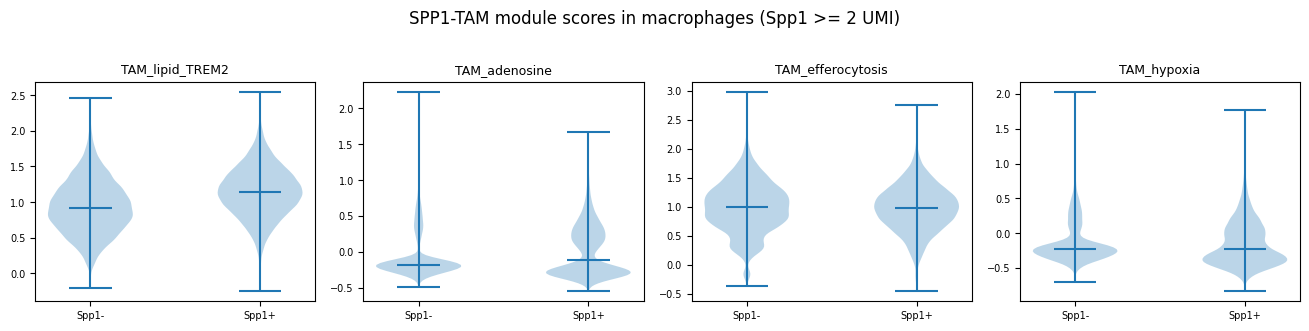

In [9]:
# Visual: module score distributions, Spp1+ vs Spp1-, at the default threshold.
pos_def = (mac_obs["Spp1_counts"] >= SPP1_THRESHOLD_DEFAULT).values
fig, axes = plt.subplots(1, len(module_cols), figsize=(3.3 * len(module_cols), 3.2), squeeze=False)
for ax, m in zip(axes.ravel(), module_cols):
    ax.violinplot([mac_obs.loc[~pos_def, m].values, mac_obs.loc[pos_def, m].values],
                  showmedians=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Spp1-", "Spp1+"], fontsize=9)
    ax.set_title(m, fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle(f"SPP1-TAM module scores in macrophages (Spp1 >= {SPP1_THRESHOLD_DEFAULT} UMI)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_module_validation.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 7. Commit to the definition

Set `SPP1_THRESHOLD_DEFAULT` in the config cell based on sections 5 + 6, then run this.
Writes `spp1_mac` (bool) and `mac_spp1_class` (Spp1_Mac / Spp1neg_Mac / Non_mac) to obs.

In [ ]:
adata.obs["is_mac"]   = mac_mask
adata.obs["spp1_mac"] = mac_mask & (spp1_counts >= SPP1_THRESHOLD_DEFAULT)

adata.obs["mac_spp1_class"] = np.where(
    adata.obs["spp1_mac"], "Spp1_Mac",
    np.where(adata.obs["is_mac"], "Spp1neg_Mac", "Non_mac"))
adata.obs["mac_spp1_class"] = adata.obs["mac_spp1_class"].astype("category")

print(f"--- committed definition: macrophage AND Spp1 >= {SPP1_THRESHOLD_DEFAULT} UMI "
      f"(cell type from {CELL_TYPE_COL}) ---")
print(adata.obs["mac_spp1_class"].value_counts().to_string())
print(f"\nSpp1_Mac = {adata.obs['spp1_mac'].sum():,} cells "
      f"({100*adata.obs['spp1_mac'].sum()/n_mac:.1f}% of macrophages, "
      f"{100*adata.obs['spp1_mac'].sum()/adata.n_obs:.2f}% of all cells)")

# Which macrophage subtype do they come from? (M2-skew would match the PDF's model)
print(f"\nSpp1_Mac by original {CELL_TYPE_COL} label:")
print(pd.crosstab(adata.obs.loc[mac_mask, CELL_TYPE_COL].astype(str),
                  adata.obs.loc[mac_mask, "spp1_mac"], normalize="index").mul(100).round(1).to_string())

## 8. Q: *In what conditions are Spp1+ macrophages found the most?*

Replicate-level (each tissue = one point), which is the only honest unit here — cell-level
n would be pseudo-replication across ~65k cells/tissue.

Two denominators, because they answer different questions:
- **`pct_of_macs`** — is the macrophage compartment *skewed* toward Spp1+? (state question)
- **`pct_of_annotated`** — are there *more* Spp1+ macs in the tissue? (abundance question)

`Unknown` cells are excluded from `pct_of_annotated` so shifting annotation rates between
tissues can't masquerade as biology.

In [ ]:
obs = adata.obs
per_tissue = []
for t, sub in obs.groupby(obs[TISSUE_COL].astype(str), observed=True):
    if len(sub) < MIN_CELLS_PER_TISSUE:
        print(f"skip {t} ({len(sub)} cells)"); continue
    n_annot = int((sub[CELL_TYPE_COL].astype(str) != "Unknown").sum())
    n_mac_t = int(sub["is_mac"].sum())
    n_spp1  = int(sub["spp1_mac"].sum())
    meta = tissue_meta.loc[t]
    per_tissue.append({
        "tissue": t, "cond": meta["cond"], "tumor_loc": meta["tumor_loc"],
        "rt_group": meta["rt_group"], "group": meta["group"],
        "mouse": sub[MOUSE_COL].astype(str).iloc[0] if MOUSE_COL in sub else None,
        "n_cells": len(sub), "n_annotated": n_annot, "n_mac": n_mac_t, "n_spp1_mac": n_spp1,
        "pct_of_macs": 100 * n_spp1 / n_mac_t if n_mac_t else np.nan,
        "pct_of_annotated": 100 * n_spp1 / n_annot if n_annot else np.nan,
        "mac_pct_of_annotated": 100 * n_mac_t / n_annot if n_annot else np.nan,
    })
abundance = pd.DataFrame(per_tissue)
abundance.to_csv(OUT_DIR / "spp1_abundance_per_tissue.csv", index=False)

print("--- per-tissue Spp1+ macrophage abundance ---")
print(abundance[["tissue", "cond", "tumor_loc", "n_mac", "n_spp1_mac",
                 "pct_of_macs", "pct_of_annotated"]].round(2).to_string(index=False))

print("\n--- summary by condition x tumor location (mean of tissue-level values) ---")
summary = (abundance.groupby(["cond", "tumor_loc"], observed=True)
           .agg(n_tissues=("tissue", "count"), n_spp1_mac=("n_spp1_mac", "sum"),
                pct_of_macs=("pct_of_macs", "mean"), pct_of_annotated=("pct_of_annotated", "mean"))
           .round(2))
print(summary.to_string())
summary.to_csv(OUT_DIR / "spp1_abundance_by_condition.csv")

In [ ]:
# Replicate dot plots: each dot = one tissue.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
groups = sorted(abundance["group"].unique())
xmap = {g: i for i, g in enumerate(groups)}
colors = {"no_RT": "#4d4d4d", "RT_direct": "#d62728", "RT_abscopal": "#1f77b4"}
rng = np.random.default_rng(0)

for ax, metric in zip(axes, ["pct_of_macs", "pct_of_annotated"]):
    for g in groups:
        sub = abundance[abundance["group"] == g]
        v = sub[metric].dropna().values
        x = xmap[g] + rng.uniform(-0.12, 0.12, len(v))
        rtg = sub["rt_group"].iloc[0] if len(sub) else "no_RT"
        ax.scatter(x, v, s=45, color=colors.get(rtg, "k"), alpha=0.85, linewidths=0)
        if len(v):
            ax.hlines(np.median(v), xmap[g] - 0.25, xmap[g] + 0.25, color="k", lw=1.5)
    ax.set_xticks(list(xmap.values()))
    ax.set_xticklabels(groups, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(f"Spp1+ macrophages: {metric}", fontsize=10)
handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=k) for k, c in colors.items()]
axes[1].legend(handles=handles, fontsize=8, frameon=False)
fig.suptitle("Spp1+ macrophage abundance (each dot = one tissue)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "spp1_abundance_by_condition.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 9. The contrasts that test the PDF's model

1. **RT vs no-RT** — does radiation raise Spp1+ TAMs at all?
2. **RT_direct vs RT_abscopal** — is it a local-damage effect or systemic?
3. **RTCyPSCA_1 vs CyPSCA_1** — RT effect holding the drug/CAR-T backbone constant (cleanest).
4. **RTCyPSCA_2 vs CyPSCA_2** — the abscopal question, backbone held constant.

With n=2-4 per group these p-values are weak by construction. **Read the effect size and
the per-replicate consistency in the dot plot above, not the p-value.**

In [ ]:
def contrast(df, col, a_filter, b_filter, a_name, b_name):
    a = df[a_filter(df)][col].dropna().values
    b = df[b_filter(df)][col].dropna().values
    if len(a) < 2 or len(b) < 2:
        return {"contrast": f"{a_name} vs {b_name}", "metric": col, "n_a": len(a), "n_b": len(b),
                "mean_a": np.mean(a) if len(a) else np.nan, "mean_b": np.mean(b) if len(b) else np.nan,
                "delta": np.nan, "cliffs_delta": np.nan, "mwu_p": np.nan}
    u = mannwhitneyu(a, b, alternative="two-sided")
    return {"contrast": f"{a_name} vs {b_name}", "metric": col, "n_a": len(a), "n_b": len(b),
            "mean_a": a.mean(), "mean_b": b.mean(), "delta": a.mean() - b.mean(),
            "cliffs_delta": 2 * u.statistic / (len(a) * len(b)) - 1, "mwu_p": u.pvalue}

CONTRASTS = [
    (lambda d: d["cond"].str.startswith("RT"),  lambda d: ~d["cond"].str.startswith("RT"), "RT_any", "no_RT"),
    (lambda d: d["rt_group"] == "RT_direct",    lambda d: d["rt_group"] == "RT_abscopal",  "RT_direct", "RT_abscopal"),
    (lambda d: d["group"] == "RTCyPSCA_1",      lambda d: d["group"] == "CyPSCA_1",        "RTCyPSCA_1", "CyPSCA_1"),
    (lambda d: d["group"] == "RTCyPSCA_2",      lambda d: d["group"] == "CyPSCA_2",        "RTCyPSCA_2", "CyPSCA_2"),
    (lambda d: d["rt_group"] == "RT_abscopal",  lambda d: d["rt_group"] == "no_RT",        "RT_abscopal", "no_RT"),
]

rows = [contrast(abundance, m, af, bf, an, bn)
        for m in ["pct_of_macs", "pct_of_annotated"]
        for af, bf, an, bn in CONTRASTS]
contrasts_df = pd.DataFrame(rows)
contrasts_df.to_csv(OUT_DIR / "spp1_abundance_contrasts.csv", index=False)

print("--- Spp1+ macrophage abundance contrasts (replicate-level) ---")
print(contrasts_df.round(3).to_string(index=False))

## 10. Handoff

Saves the per-cell labels so scripts 02-04 don't recompute them.

In [ ]:
handoff_cols = [TISSUE_COL, CELL_TYPE_COL, "Spp1_counts", "is_mac", "spp1_mac", "mac_spp1_class"] + module_cols
adata.obs[handoff_cols].to_parquet(OUT_DIR / "spp1_cell_labels.parquet")

print("saved ->", OUT_DIR)
for f in sorted(OUT_DIR.glob("*.csv")) + sorted(OUT_DIR.glob("*.parquet")):
    print("  ", f.name)

print(f"""
==================== SUMMARY — report these back ====================
Spp1 threshold used      : >= {SPP1_THRESHOLD_DEFAULT} UMI
Macrophages total        : {n_mac:,}
Spp1+ macrophages        : {int(adata.obs['spp1_mac'].sum()):,} ({100*adata.obs['spp1_mac'].sum()/n_mac:.1f}% of macs)
Tissues analyzed         : {len(abundance)}
Min Spp1+ macs / tissue  : {int(abundance['n_spp1_mac'].min())}   <- if this is < ~50, per-tissue
Median Spp1+ macs/tissue : {int(abundance['n_spp1_mac'].median())}      spatial stats in 02/03 will be underpowered

CHECK BEFORE CONTINUING:
 1. Sec 5 sweep  - does the {ctrl_label}-cell (spillover) rate stay far below the mac rate?
 2. Sec 6 deltas - do Spp1+ macs separate on TAM_lipid_TREM2 / TAM_hypoxia / TAM_adenosine?
    If deltas are ~0, the label is ambient RNA and 02-04 would be built on sand.
 3. Sec 8 counts - enough Spp1+ macs per tissue to support hotspot/neighborhood stats?
=====================================================================
""")